In [1]:
from pathlib import Path

LISTINGS = str(Path("../data") / "melb" / "melb_listings_jun_25.csv")

In [2]:
import pandas as pd

raw_df = pd.read_csv(LISTINGS)

In [3]:
def process_prices(df):
    """
    converts prices to floats and removes empty price instances
    """
    df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)
    df = df[df['price'] > 0]
    return df

In [9]:
import ast
def str_2_py_object(df, targets = ['amentities']):
    df[targets] = df[targets].applymap(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
    return df

In [61]:
def pipeline(df, steps):
    for fn in steps:
        df = fn(df)
    return df

In [6]:
def discard_useless_columns(df, to_discard = []):
    return df.drop(columns=to_discard)

In [ ]:
USELESS = ['id', 'listing_url', 'scrape_id', 'host_url', 'host_thumbnail_url', 'source', 'picture_url', 'host_picture_url']

In [ ]:
df = pipeline(
                raw_df.copy(), 
                steps = [
                            process_prices, 
                            lambda x : str_2_py_object(x, targets=['amenities']),
                            lambda x : discard_useless_columns(x, to_discard = USELESS),
                            
                        ]
            )

C:\Users\olism\AppData\Local\Temp\ipykernel_29736\633348319.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[targets] = df[targets].applymap(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [98]:
df.columns

Index(['id', 'last_scraped', 'name', 'description', 'neighborhood_overview',
       'host_id', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availabilit

In [5]:
df['price'].describe()

count     18539.000000
mean        241.812611
std        1365.709149
min          17.000000
25%         106.000000
50%         153.000000
75%         229.500000
max      118611.000000
Name: price, dtype: float64

In [11]:
import numpy as np
import scipy.spatial as spatial

def compute_listing_density(df, radius=0.01):
    points = list(zip(df['latitude'], df['longitude']))
    tree = spatial.KDTree(np.array(points))
    neighbors = tree.query_ball_tree(tree, radius)
    frequency = np.array(map(len, neighbors))
    density = frequency/radius**2
    return density

In [13]:
MELB_GEO = str(Path("../data") / "melb_geojson.geojson")

In [12]:
import string, re, functools, ast, tqdm
PERMITTED_CHARS = string.ascii_letters + string.digits + " " + "!?@#&()[]{}.,;:-_"
SPLIT_PATTERN = re.compile(r"\,|\d\.| with | and ")

def tokenize_amenities(text):
    text = ''.join([char for char in text if char in PERMITTED_CHARS])
    return re.split(SPLIT_PATTERN, text)
    
def preprocess_amenities(df) -> list[list[str]]:
    return [
                list(
                    map(
                        lambda amenity: amenity.strip(),
                        functools.reduce(
                                        lambda a,b : a+b, 
                                        [tokenize_amenities(x) for x in row["amenities"] if pd.notna(x)]
                                        )
                        )
                ) for _, row in tqdm.tqdm(df.iterrows(), total=len(df), desc = "Preprocessing amenities")
            ]
    


In [60]:
amentities = preprocess_amenities(df)

100%|██████████| 25801/25801 [00:36<00:00, 704.57it/s]


In [49]:
from bertopic import BERTopic
class TextFeatureExtractor:
    def __init__(self, embeddings):
        self.topic_model = BERTopic()
        self.embeddings = embeddings
        
    def fit(self, documents):
        embeddings = self.embeddings.get_embeddings(documents)    
        self.topics, self.probs = self.topic_model.fit_transform(documents, embeddings=embeddings)
     
    def transform(self, new_documents, transform_embeddings_path=None):
        embeddings = self.embeddings.get_embeddings(new_documents)
        return self.topic_model.transform(new_documents, embeddings=embeddings)

In [45]:
import json
import numpy as np
from pathlib import Path

class EmbeddingCache:
    def __init__(self, encoder, cache_path):
        self.cache_path = Path(cache_path)
        self.encoder = encoder
        self.token_embedding_mapping = {}
        self.embeddings = np.empty((0, self.encoder.get_sentence_embedding_dimension()))
        if not self.cache_path.exists():
            self.cache_path.mkdir(parents=True)
        
    def load(self):
        with open(self.cache_path / "token_embedding_mapping.json", "r") as f:
            self.token_embedding_mapping = json.load(f)
        self.embeddings = np.load(self.cache_path / "embeddings.npy")
        
    def save(self):
        with open(self.cache_path / "token_embedding_mapping.json", "w") as f:
            json.dump(self.token_embedding_mapping, f)
        np.save(self.cache_path / "embeddings.npy", self.embeddings)    
    
    def get_embeddings(self, tokens):
        missing_tokens = [token for token in tokens if token not in self.token_embedding_mapping]
        if missing_tokens:
            new_embeddings = self.encoder.encode(missing_tokens)
            start_index = len(self.embeddings)
            self.embeddings = np.vstack([self.embeddings, new_embeddings])
            for i, token in enumerate(missing_tokens):
                self.token_embedding_mapping[token] = start_index + i
            self.save()
        indices = [self.token_embedding_mapping[token] for token in tokens]
        return self.embeddings[indices]
        

In [18]:
from sentence_transformers import SentenceTransformer
def get_semantic_clustering_alg(cache_dir):
    encoder = SentenceTransformer('all-MiniLM-L6-v2')
    return TextFeatureExtractor(EmbeddingCache(encoder, cache_dir))

In [35]:
encoder = SentenceTransformer('all-MiniLM-L6-v2')

In [50]:
alg = TextFeatureExtractor(EmbeddingCache(encoder, "../data/embedding_cache_1"))

In [51]:
alg.fit(data)

In [ ]:
result = alg.transform()

In [39]:
amenities = preprocess_amenities(df)

In [41]:
feat_extractor = TextFeatureExtractor(cached_embeddings_path="../data/amenities_embeddings.npy")

In [28]:
info["Representative_Docs"].to_csv("../outputs/representative_docs.csv", index=False)

In [15]:
MELB_GEO = str(Path("../data") / "melb" / "melb_geojson.geojson")

In [58]:
import geopandas as gpd
from shapely.geometry import Point
def impute_neighborhoods(df, gdf, lon_col="longitude", lat_col="latitude"):
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
        

    points_gdf = gpd.GeoDataFrame(
        df, 
        geometry=geometry,
        crs='EPSG:4326'
    )

    if gdf.crs != points_gdf.crs:
        gdf = gdf.to_crs(points_gdf.crs)

    result = gpd.sjoin(
        points_gdf, 
        gdf,
        how='left',
        predicate='within'  
    )
    return result

In [59]:
df = impute_neighborhoods(df, gdf)

In [ ]:
numericals = [
                'host_response_time', 'host_response_rate', 'host_acceptance_rate',
                'host_listings_count', 'host_total_listings_count', 'host_verifications',
                'latitude', 'longitude', 
]

Index(['last_scraped', 'name', 'description', 'neighborhood_overview',
       'host_id', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_left', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability

In [100]:
def impute_numerical_features(df, targets):
    MARGIN = 0.1
    for target in targets:
        median = df[target].median()
        mean = df[target].mean()
        if abs(median - mean)/mean > MARGIN:
            df[target] = df[target].fillna(median)
        else:
            df[target] = df[target].fillna(mean)
        
    return df
    

In [101]:
def impute_categorical_features(df, targets):
    for target in targets:
        mode = df[target].mode()
    return df

       neighbourhood neighbourhood_group  \
0  Greater Dandenong                None   
1            Wyndham                None   
2               Hume                None   
3        Hobsons Bay                None   
4           Kingston                None   

                                            geometry  
0  MULTIPOLYGON (((145.1417 -37.93139, 145.14254 ...  
1  MULTIPOLYGON (((144.82749 -37.8228, 144.82654 ...  
2  MULTIPOLYGON (((144.67238 -37.5678, 144.67127 ...  
3  MULTIPOLYGON (((144.90275 -37.84707, 144.9034 ...  
4  MULTIPOLYGON (((145.1417 -37.93139, 145.1419 -...  


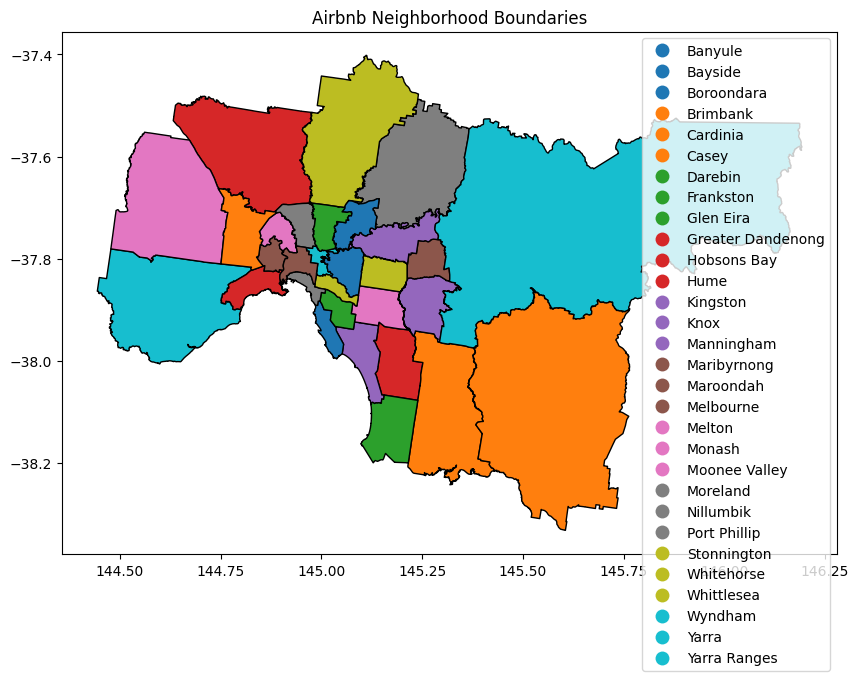

In [96]:
import geopandas as gpd
import matplotlib.pyplot as plt


gdf = gpd.read_file(MELB_GEO)


print(gdf.head())

gdf.plot(column="neighbourhood", figsize=(10, 8), legend=True, edgecolor='black')
plt.title("Airbnb Neighborhood Boundaries")
plt.show()


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Category'], drop_first=True)